# Visa Approval Prediction Model

## Objective

The objective of this notebook is to build machine learning models that predict visa approval outcomes and
identify the most influential factors affecting certification decisions.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Load Dataset

In [2]:
df = pd.read_csv("../data/Visadataset.csv")

df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


# Drop Unnecessary Column

In [3]:
df.drop("case_id", axis=1, inplace=True)

# Encode Categorical Variables

In [4]:
cat_cols = df.select_dtypes(include="object").columns
num_cols = df.select_dtypes(exclude='object').columns

le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [5]:
df.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,1,2,0,0,14513,2007,4,592.2029,0,1,1
1,1,3,1,0,2412,2002,2,83425.6500,3,1,0
2,1,0,0,1,44444,2008,4,122996.8600,3,1,1
3,1,0,0,0,98,1897,4,83434.0300,3,1,1
4,0,3,1,0,1082,2005,3,149907.3900,3,1,0


# Define Features and Target

In [6]:
X = df.drop("case_status", axis=1)

y = df["case_status"]

In [7]:
print(X.shape)
print(y.shape)

(25480, 10)
(25480,)


# Train-Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

## Train-Test Split

The dataset was divided into:

- 80% Training Data
- 20% Testing Data

This ensures unbiased model evaluation.

# Logistic Regression

In [9]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

C:\Users\lenovo\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Metrics:

In [10]:
lr_accuracy = accuracy_score(y_test, lr_pred)

lr_precision = precision_score(y_test, lr_pred)

lr_recall = recall_score(y_test, lr_pred)

lr_f1 = f1_score(y_test, lr_pred)

print("Accuracy:", lr_accuracy)
print("Precision:", lr_precision)
print("Recall:", lr_recall)
print("F1:", lr_f1)

Accuracy: 0.6987833594976453
Precision: 0.6886792452830188
Recall: 0.17227138643067846
F1: 0.27560169891458236


# Decision Tree

In [11]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

## Metrics:

In [12]:
dt_accuracy = accuracy_score(y_test, dt_pred)

dt_precision = precision_score(y_test, dt_pred)

dt_recall = recall_score(y_test, dt_pred)

dt_f1 = f1_score(y_test, dt_pred)

# Random Forest

In [14]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

## Metrics:

In [15]:
rf_accuracy = accuracy_score(y_test, rf_pred)

rf_precision = precision_score(y_test, rf_pred)

rf_recall = recall_score(y_test, rf_pred)

rf_f1 = f1_score(y_test, rf_pred)

# Compare Models

In [16]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy
    ],
    "Precision": [
        lr_precision,
        dt_precision,
        rf_precision
    ],
    "Recall": [
        lr_recall,
        dt_recall,
        rf_recall
    ],
    "F1 Score": [
        lr_f1,
        dt_f1,
        rf_f1
    ]
})

results.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.736068,0.632175,0.493805,0.554488
0,Logistic Regression,0.698783,0.688679,0.172271,0.275602
1,Decision Tree,0.662088,0.491969,0.487906,0.489929


# Confusion Matrix (Best Model)

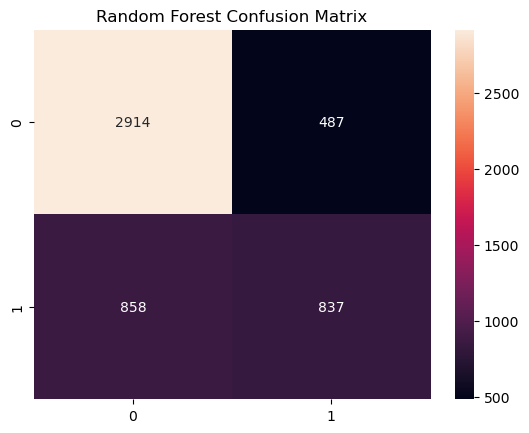

In [17]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Random Forest Confusion Matrix")
plt.show()

# Feature Importance

In [20]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
7,prevailing_wage,0.268565
4,no_of_employees,0.245801
5,yr_of_estab,0.192423
1,education_of_employee,0.109318
6,region_of_employment,0.046737
0,continent,0.045765
2,has_job_experience,0.037177
8,unit_of_wage,0.025180
3,requires_job_training,0.015051
9,full_time_position,0.013982


# PLOT

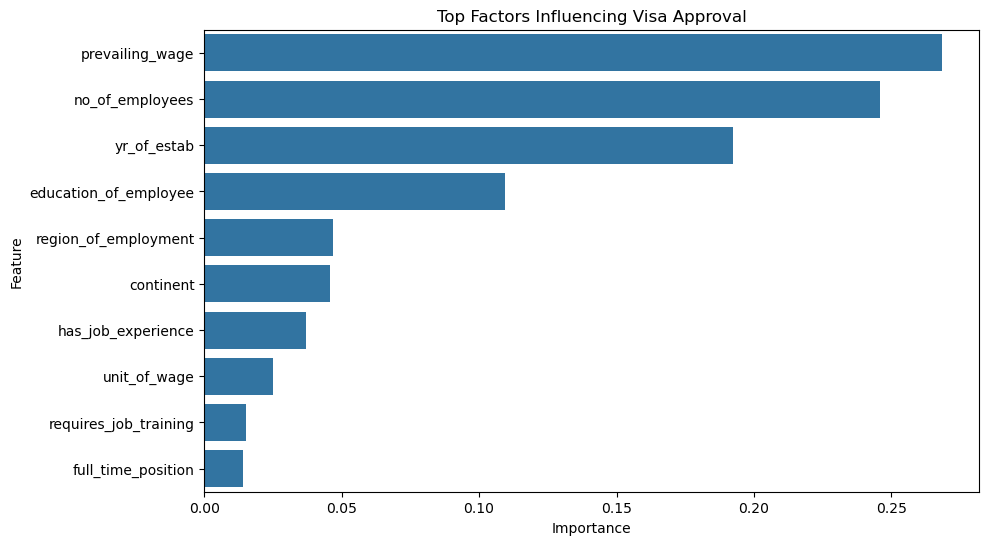

In [21]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top Factors Influencing Visa Approval")
plt.show()

# Final Conclusion

# Model Conclusion

Three machine learning models were trained and evaluated:

1. Logistic Regression
2. Decision Tree
3. Random Forest

## Key Findings

- Random Forest achieved the best overall performance.
- Prevailing wage was one of the strongest predictors.
- Education level significantly influenced approval decisions.
- Work experience positively impacted certification outcomes.

## Business Value

Organizations can use predictive models to estimate visa approval likelihood and improve hiring strategies by focusing on candidates with stronger approval characteristics.